# Setup

In [42]:
%matplotlib inline

import os, sys, warnings, math

import numpy as np
import pandas as pd
from tqdm import tqdm
import src.utils as utils
from src.neural_network import ModelDataManager
from scipy.ndimage import uniform_filter1d

import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 8})
plt.rcParams["svg.fonttype"] = "none"
plt.rc('font', family='Arial')
import seaborn as sns
sns.set_style("white")

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# Files and parameters

In [43]:
# directories and files
model_params_name = 'model_params_202606d'
username = os.getenv('USER')
if sys.platform == 'darwin':
    if username == 'ahmad':
        datadir = '/Users/ahmad/software/snaplab_github/neuro_rnn/data'
        modeldir = '/Users/ahmad/data/rutgers/neuro_rnn/results/pytorch/model/' + model_params_name
        # modeldir = '/Volumes/Sabrent_2TB/rutgers/neuro_rnn/data/' + model_params_name
        # outdir = modeldir
        outdir = '/Users/ahmad/Desktop/figs'
elif sys.platform == 'linux':
    if username == 'ab2792':
        datadir = '/home/ab2792/software/snaplab_github/neuro_rnn/data'
        modeldir = '/home/ab2792/data/neuro_rnn/results/pytorch/model'
        # outdir = modeldir
        outdir = 'Users/ahmad/Desktop/figs'
    elif username == 'lindenmp':
        datadir = '/home/lindenmp/research_projects/neuro_rnn/data'
        modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/model_cpu'
        outdir = '/home/lindenmp/research_projects/neuro_rnn/results/figs'

model_params_file = os.path.join(datadir, model_params_name + '.csv')

check_only = False
verbose = True
save_figs = True

# plotting / analysis horizon
n_epochs_plot = 50000   # max epoch to plot & analyze (None = use all logged epochs)
epochs_per_log = None   # epochs between logged points (None = infer per model from the outputs file)

# select rows from model params CSV
# rows_to_plot = None
rows_to_plot = [10, 11, 13]
rows_to_plot = [0, 1, 2]

model_params, task_names, n_tasks, kernel_labels, n_kernels = utils.get_params_dataframe(
    model_params_file, rows=rows_to_plot, verbose=verbose)
n_models = len(model_params)

display(model_params)

Tasks:
------
DelayMatchSampleDistractor1D-v0
 
Kernel types:
-------------
Unmasked Reg. 
Masked Reg. 
Masked Eucl.
 
DataFrame keys:
---------------
task
seq_len_multi
time_step
alpha
rec_noise
init_hh_w
rnn_model
hidden_size
batch_size
learning_rate
n_epochs
reg_type
reg_weight
kernel_type
kernel_normalization
mask_weights
n_runs
null_perms
null_seed
null_run
null_run_ids
kernel_label
task_label
task_index
kernel_index
task_no_modifier
task_modifier
task_with_modifier
n_io
seq_len
config
file_str_models
file_str_outputs
env_kwargs
model_index
 


,task,seq_len_multi,time_step,alpha,rec_noise,init_hh_w,rnn_model,hidden_size,batch_size,learning_rate,...,task_no_modifier,task_modifier,task_with_modifier,n_io,seq_len,config,file_str_models,file_str_outputs,env_kwargs,model_index
0,DelayMatchSampleDistractor1D-v0,5,50,0.1,0.05,-0.01 0.01,rnn-tanh,100,32,0.001,...,DelayMatchSampleDistractor1D-v0,,DelayMatchSampleDistractor1D-v0,na,520,"{'time_step': 50, 'batch_size': 32, 'rnn_model...",DelayMatchSampleDistractor1D-v0-520-rnn-tanh-1...,DelayMatchSampleDistractor1D-v0-520-rnn-tanh-1...,"{'dt': 50, 'timing': {'fixation': 200, 'sample...",0
1,DelayMatchSampleDistractor1D-v0,5,50,0.1,0.05,-0.01 0.01,rnn-tanh,100,32,0.001,...,DelayMatchSampleDistractor1D-v0,,DelayMatchSampleDistractor1D-v0,14-27,520,"{'time_step': 50, 'batch_size': 32, 'rnn_model...",DelayMatchSampleDistractor1D-v0-520-rnn-tanh-1...,DelayMatchSampleDistractor1D-v0-520-rnn-tanh-1...,"{'dt': 50, 'timing': {'fixation': 200, 'sample...",1
2,DelayMatchSampleDistractor1D-v0,5,50,0.1,0.05,-0.01 0.01,rnn-tanh,100,32,0.001,...,DelayMatchSampleDistractor1D-v0,,DelayMatchSampleDistractor1D-v0,14-27,520,"{'time_step': 50, 'batch_size': 32, 'rnn_model...",DelayMatchSampleDistractor1D-v0-520-rnn-tanh-1...,DelayMatchSampleDistractor1D-v0-520-rnn-tanh-1...,"{'dt': 50, 'timing': {'fixation': 200, 'sample...",2


# Load data

In [44]:
if check_only:
    
    found_count = 0
    for model_idx in range(n_models):
        this = model_params.iloc[model_idx]
        file_path = os.path.join(modeldir, this.file_str_outputs)
        file_exists = os.path.isfile(file_path)
        if file_exists:
            found_count += 1
        else:
            print(f'Not found ... {this.file_str_outputs} ({model_idx})')
    print(f'Found {found_count}/{n_models} files.')
    
else:
    
    loaded_accuracy = []
    loaded_log_freq = []   # inferred epochs-between-logged-points, per model
    loaded_loss = []
    loaded_loss_task = []
    loaded_loss_spatial = []
    
    for model_idx in tqdm(np.arange(n_models), desc='Loading data'):
        
        # get model details
        this = model_params.iloc[model_idx]
        utils.check_if_supported(task=this.task_no_modifier, modifier=this.task_modifier)

        # get data file name
        file_path = os.path.join(modeldir, this.file_str_outputs)

        try:
            output_manager = ModelDataManager(file_path)
            _, logged_epochs, _ = output_manager.get_info()
            final_epoch = logged_epochs[-1]
            
            # load test accuracy
            loaded_accuracy.append(output_manager.load_key_across_runs('test_accuracy', epoch=final_epoch))

            # infer logging cadence: (final_epoch + 1) spread over the logged points
            acc_len = loaded_accuracy[-1][0].shape[0]
            loaded_log_freq.append(int(round((final_epoch + 1) / max(acc_len - 1, 1))))
            
            # load training losses
            try:
                loaded_loss.append(output_manager.load_key_across_runs('training_loss', epoch=final_epoch))
                loaded_loss_task.append(output_manager.load_key_across_runs('training_loss_task', epoch=final_epoch))
                loaded_loss_spatial.append(output_manager.load_key_across_runs('training_loss_spatial', epoch=final_epoch))
            except Exception as e:
                print(f"Loss data not available for model {model_idx}: {e}")
                loaded_loss.append(None)
                loaded_loss_task.append(None)
                loaded_loss_spatial.append(None)
                
        except:
            print("An error occurred:", sys.exc_info()[0])
            print("Exception message:", sys.exc_info()[1])

Loading data: 100%|██████████| 3/3 [00:00<00:00, 15.87it/s]


# Test accuracy

Plotting: 100%|██████████| 3/3 [00:00<00:00, 360.49it/s]


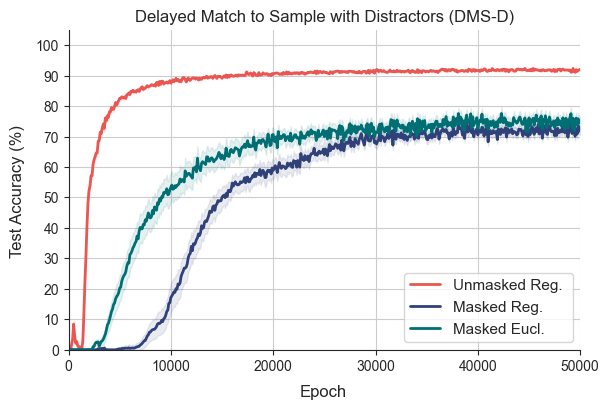

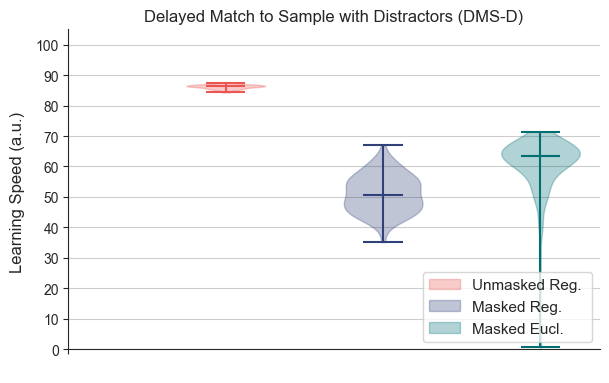

In [45]:
if not check_only:
    
    color_palette = utils.get_my_colors(cat_trio=False, as_list=True)
    
    smooth_data = 0
    chance_line = None # 100 / 3  # chance accuracy (%); set to None to omit

    # initialise figures
    size_scale = 2.0
    font_size = int(6 * size_scale)
    n_fig_columns = min((3, n_tasks))
    n_fig_rows = math.ceil(n_tasks / n_fig_columns)
    fig_size_w = 3 * n_fig_columns * size_scale
    fig_size_h = 2 * n_fig_rows * size_scale
    f_plots, ax_plots = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                                     squeeze=True, sharex=False, sharey=True)
    f_violin, ax_violin = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                                       squeeze=True, sharex=False, sharey=True)
    plt.rcParams['font.size'] = font_size
    xlims_plots = np.zeros(n_tasks)
    violin_bodies = []
    all_means = [{} for _ in range(n_tasks)]

    for model_idx in tqdm(np.arange(n_models), desc='Plotting'):
        
        this = model_params.iloc[model_idx]
        
        try:
            test_accuracy_all_runs = loaded_accuracy[model_idx]
            
            # extract accuracy from each run
            test_accuracy = np.zeros((this.n_runs, test_accuracy_all_runs[0].shape[0] - 1))
            for run in np.arange(this.n_runs):
                test_accuracy[run, :] = test_accuracy_all_runs[run][1:] * 100
            if smooth_data > 0:
                test_accuracy = uniform_filter1d(input=test_accuracy, size=smooth_data, axis=1)

            # epochs between logged points (explicit, else inferred per model)
            ep_log = epochs_per_log if epochs_per_log is not None else loaded_log_freq[model_idx]
            # keep only logged points up to n_epochs_plot (None = all); x in epochs
            n_logged_keep = test_accuracy.shape[1]
            if n_epochs_plot is not None:
                n_logged_keep = min(n_logged_keep, max(1, round(n_epochs_plot / ep_log)))
            test_accuracy = test_accuracy[:, :n_logged_keep]
            x = np.arange(1, n_logged_keep + 1) * ep_log

            # compute mean and CI across runs
            accuracy_mean_runs = test_accuracy.mean(axis=0)
            accuracy_std_runs = test_accuracy.std(axis=0)
            ci = 1.96 * (accuracy_std_runs / np.sqrt(test_accuracy.shape[0]))
            ci_lower = accuracy_mean_runs - ci
            ci_upper = accuracy_mean_runs + ci
            
            # compute mean of each run across time
            accuracy_mean_epochs = test_accuracy.mean(axis=1)
            
            all_means[this.task_index][this.kernel_index] = accuracy_mean_runs

            # plot mean accuracy vs. time
            f_plots.axes[this.task_index].plot(x, accuracy_mean_runs,
                                              color=color_palette[this.kernel_index],
                                              label=str(this.kernel_label),
                                              linewidth=2)
            f_plots.axes[this.task_index].fill_between(x, ci_lower, ci_upper,
                                                       color=color_palette[this.kernel_index], alpha=0.1)
            xlims_plots[this.task_index] = np.max((xlims_plots[this.task_index], x[-1]))
            
            # plot time-averaged accuracy as violin plot
            violin_parts = f_violin.axes[this.task_index].violinplot(
                dataset=accuracy_mean_epochs, positions=[this.kernel_index], showmedians=True)
            for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
                vp = violin_parts[partname]
                vp.set_edgecolor(color_palette[this.kernel_index])
            for pc in violin_parts['bodies']:
                pc.set_facecolor(color_palette[this.kernel_index])
                pc.set_edgecolor(color_palette[this.kernel_index])
            if this.task_index == 0:
                violin_bodies.append(violin_parts['bodies'][0])
            
        except:
            print("An error occurred:", sys.exc_info()[0])
            print("Exception message:", sys.exc_info()[1])

    # set title and labels for line plots
    for task_index in np.arange(n_tasks):
        xmax = xlims_plots[task_index]
        f_plots.axes[task_index].set_xlim([0, xmax + 10])
        f_plots.axes[task_index].set_ylim([0, 105])
        f_plots.axes[task_index].set_xticks(np.arange(0, xmax + 10, int(xmax / 5)))
        f_plots.axes[task_index].set_yticks(np.arange(0, 100 + 1, 10))
        f_plots.axes[task_index].tick_params(bottom=True, left=True)
        if chance_line is not None:
            f_plots.axes[task_index].axhline(chance_line, color='dimgray',
                                             linestyle='--', linewidth=1, zorder=0)
            f_plots.axes[task_index].text(xmax + 10, chance_line, 'chance', color='dimgray',
                                          ha='right', va='bottom', fontsize=font_size)
        if task_index == 0:
            f_plots.axes[task_index].legend(loc='lower right')
        f_plots.axes[task_index].set_title(utils.get_task_label(task_names[task_index]),
                                           fontsize=font_size)
        f_plots.axes[task_index].grid()
    f_plots.text(0.51, 0.0, 'Epoch', ha='center', va='center')
    f_plots.text(0.0, 0.5, 'Test Accuracy (%)', ha='center', va='center', rotation='vertical')
    
    # set title and labels for violin plots
    for task_index in np.arange(n_tasks):
        f_violin.axes[task_index].set_ylim([0, 105])
        f_violin.axes[task_index].set_xticks((-1,))
        f_violin.axes[task_index].set_xticklabels([' '])
        f_violin.axes[task_index].set_yticks(np.arange(0, 100 + 1, 10))
        f_violin.axes[task_index].tick_params(bottom=True, left=True)
        if task_index == 0:
            f_violin.axes[task_index].legend(violin_bodies, kernel_labels, loc='lower right')
        f_violin.axes[task_index].set_title(utils.get_task_label(task_names[task_index]),
                                            fontsize=font_size)
        f_violin.axes[task_index].grid()
    f_violin.text(0.0, 0.5, 'Learning Speed (a.u.)', ha='center', va='center', rotation='vertical')
    
    sns.despine(fig=f_plots, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
    sns.despine(fig=f_violin, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
    
    f_plots.tight_layout()
    f_violin.tight_layout()
    plt.show()
    
    # save svg
    if save_figs:
        models_file = os.path.splitext(os.path.basename(model_params_file))[0]
        f_plots.savefig(os.path.join(outdir, 'accuracy_{:}_plots.svg'.format(models_file)),
                        dpi=300, bbox_inches='tight', pad_inches=0.01)
        f_violin.savefig(os.path.join(outdir, 'accuracy_{:}_violin.svg'.format(models_file)),
                         dpi=300, bbox_inches='tight', pad_inches=0.01)

In [46]:
# ---- Per-run sigmoid fits (feeds the convergence-horizon cell below) ----
# Fit acc(t) = a / (1 + exp(-k*(t - t0))) to each run and store:
#   speed[task][kernel]      -> per-run t0 / k / a (+ censored count)
#   mean_fit[(task, kernel)] -> (x, mean_curve, ci_lower, ci_upper, popt)
if not check_only:
    from scipy.optimize import curve_fit

    def logistic(t, a, k, t0):
        return a / (1.0 + np.exp(-k * (t - t0)))

    def fit_logistic(xv, yv):
        a0 = max(float(np.nanmax(yv)), 1.0)
        above = np.where(yv >= a0 / 2.0)[0]            # rough inflection guess
        t0_0 = float(xv[above[0]]) if above.size else float(xv[xv.size // 2])
        k0 = 4.0 / (xv[-1] - xv[0] + 1e-9)
        p0 = [a0, k0, t0_0]
        bounds = ([0.0, 0.0, xv[0]], [105.0, np.inf, xv[-1] * 1.5])
        popt, _ = curve_fit(logistic, xv, yv, p0=p0, bounds=bounds, maxfev=20000)
        return popt

    chance = chance_line if chance_line is not None else 0.0
    # speed[task][kernel] -> per-run fit params + censored count
    speed = {ti: {ki: {'t0': [], 'k': [], 'a': [], 'censored': 0}
                  for ki in range(n_kernels)} for ti in range(n_tasks)}
    mean_fit = {}  # (task, kernel) -> (x, mean_curve, ci_lower, ci_upper, popt|None)

    for model_idx in range(n_models):
        this = model_params.iloc[model_idx]
        test_accuracy_all_runs = loaded_accuracy[model_idx]

        test_accuracy = np.zeros((this.n_runs, test_accuracy_all_runs[0].shape[0] - 1))
        for run in range(this.n_runs):
            test_accuracy[run, :] = test_accuracy_all_runs[run][1:] * 100

        # epochs between logged points (explicit, else inferred per model)
        ep_log = epochs_per_log if epochs_per_log is not None else loaded_log_freq[model_idx]
        # keep only logged points up to n_epochs_plot (None = all); x in epochs
        n_logged_keep = test_accuracy.shape[1]
        if n_epochs_plot is not None:
            n_logged_keep = min(n_logged_keep, max(1, round(n_epochs_plot / ep_log)))
        test_accuracy = test_accuracy[:, :n_logged_keep]
        x = np.arange(1, n_logged_keep + 1) * ep_log

        ti, ki = this.task_index, this.kernel_index
        for run in range(test_accuracy.shape[0]):
            try:
                a, k, t0 = fit_logistic(x, test_accuracy[run, :])
                # censor runs that never really learn or invert past the window
                if a <= chance or t0 > x[-1]:
                    speed[ti][ki]['censored'] += 1
                    continue
                speed[ti][ki]['t0'].append(t0)
                speed[ti][ki]['k'].append(k)
                speed[ti][ki]['a'].append(a)
            except Exception:
                speed[ti][ki]['censored'] += 1

        # mean curve + 95% CI across runs (same as the accuracy cell)
        mean_curve = test_accuracy.mean(axis=0)
        ci = 1.96 * test_accuracy.std(axis=0) / np.sqrt(test_accuracy.shape[0])
        try:
            popt = fit_logistic(x, mean_curve)
        except Exception:
            popt = None
        mean_fit[(ti, ki)] = (x, mean_curve, mean_curve - ci, mean_curve + ci, popt)

    # ---- summary: fit counts, censoring, median t0/k per group ----
    for ti in range(n_tasks):
        for ki in range(n_kernels):
            n_ok = len(speed[ti][ki]['t0'])
            n_cen = speed[ti][ki]['censored']
            if not (n_ok or n_cen):
                continue
            if n_ok:
                med_t0 = np.median(speed[ti][ki]['t0'])
                med_k = np.median(speed[ti][ki]['k'])
                print(f"task {ti} / {kernel_labels[ki]}: {n_ok} fit, {n_cen} censored | "
                      f"median t0={med_t0:.0f} epochs, median k={med_k:.2e}")
            else:
                print(f"task {ti} / {kernel_labels[ki]}: 0 fit, {n_cen} censored")

task 0 / Unmasked Reg. : 100 fit, 0 censored | median t0=2166 epochs, median k=1.71e-03
task 0 / Masked Reg. : 100 fit, 0 censored | median t0=12997 epochs, median k=5.52e-04
task 0 / Masked Eucl.: 99 fit, 1 censored | median t0=6569 epochs, median k=9.70e-04


=== Delayed Match to Sample with Distractors (DMS-D) (converged = 95% of asymptote) ===
  Unmasked Reg.    median t_conv=   3879  p95=   5186  (n=100)
  Masked Reg.      median t_conv=  18303  p95=  35224  (n=100)
  Masked Eucl.     median t_conv=  10305  p95=  19641  (n=99)
  slowest: Masked Reg.  -> p95=35224, +5% margin, rounded -> suggested stop T = 40000 epochs



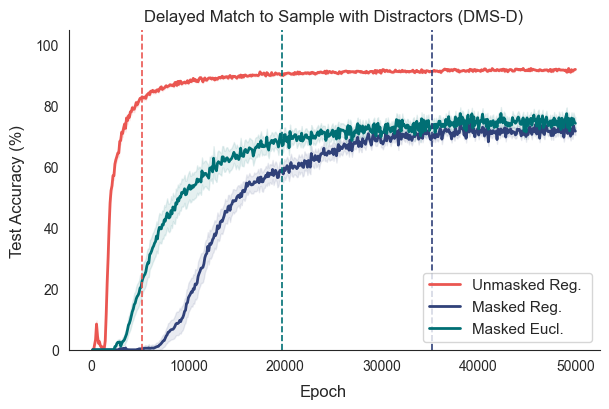

=== Delayed Match to Sample with Distractors (DMS-D): t_conv model comparisons (Mann-Whitney U, Holm-corrected) ===
  Unmasked Reg.  vs Masked Reg. : p=2.56e-34, Holm p=7.69e-34 *** | Δmedian=-14424 ep, Cliff's δ=-1.00 (large)
  Unmasked Reg.  vs Masked Eucl.: p=3.74e-34, Holm p=7.69e-34 *** | Δmedian=-6426 ep, Cliff's δ=-1.00 (large)
  Masked Reg.  vs Masked Eucl.: p=9.64e-19, Holm p=9.64e-19 *** | Δmedian=+7998 ep, Cliff's δ=+0.73 (large)


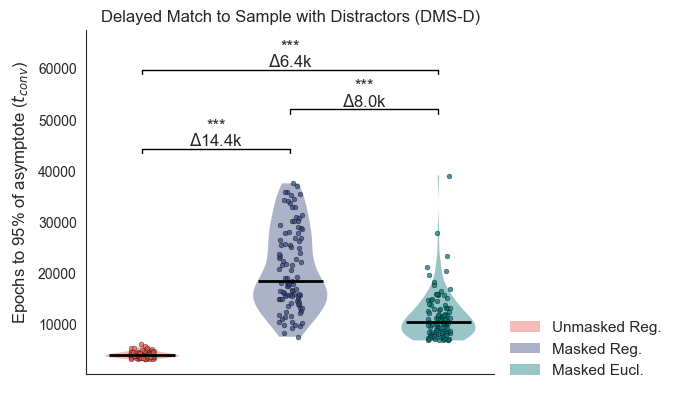

In [47]:
# ---- Suggested "training complete" horizon from the fitted curves ----
# Reuses the per-run fits in `speed` (run the sigmoid-fit cell first).
# Per run: epoch to reach fraction f of its OWN asymptote:
#   t_conv = t0 + ln(f / (1 - f)) / k          (logistic)
# Per-model criterion = the conv_pctile of that model's t_conv (drawn as a
# vertical line on the curves). Overall horizon T = slowest model's
# criterion + margin (printed), i.e. the epoch where every model has plateaued.
if not check_only:
    from scipy.stats import mannwhitneyu
    from itertools import combinations

    conv_frac   = 0.95     # fraction of asymptote that counts as "converged"
    conv_pctile = 95       # percentile of per-run t_conv within a model
    conv_margin = 0.05     # headroom added to the chosen horizon
    conv_round  = 5000     # round the suggested T up to nearest this many epochs

    def _p_stars(p):
        return '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 0.05 else 'ns'

    def _fmt_ep(v):
        return f"{v/1000:.1f}k" if abs(v) >= 1000 else f"{v:.0f}"

    def _cliff_mag(d):
        # Romano et al. thresholds for |Cliff's delta|
        d = abs(d)
        return ('negligible' if d < 0.147 else 'small' if d < 0.33
                else 'medium' if d < 0.474 else 'large')

    def _holm(pvals):
        # Holm-Bonferroni step-down adjustment
        pvals = np.asarray(pvals, dtype=float)
        order = np.argsort(pvals)
        m = pvals.size
        adj = np.empty(m)
        running = 0.0
        for rank, idx in enumerate(order):
            running = max(running, (m - rank) * pvals[idx])
            adj[idx] = min(running, 1.0)
        return adj

    ln_term = np.log(conv_frac / (1.0 - conv_frac))
    suggested_T = {}
    crit_store = {}    # task -> {kernel: per-model criterion epoch (conv_pctile of t_conv)}
    tconv_store = {}   # task -> {kernel: per-run t_conv array} (for the violins)

    for ti in range(n_tasks):
        # per-run t_conv for each kernel (drop non-finite, e.g. k ~ 0)
        tconv_by_kernel = {}
        for ki in range(n_kernels):
            t0s = np.asarray(speed[ti][ki]['t0'], dtype=float)
            ks = np.asarray(speed[ti][ki]['k'], dtype=float)
            if t0s.size == 0:
                continue
            tconv = t0s + ln_term / np.where(ks > 0, ks, np.nan)
            tconv = tconv[np.isfinite(tconv)]
            if tconv.size:
                tconv_by_kernel[ki] = tconv
        if not tconv_by_kernel:
            continue
        tconv_store[ti] = tconv_by_kernel

        # per-model criterion = conv_pctile of t_conv; slowest governs horizon T
        pct = {ki: np.percentile(v, conv_pctile) for ki, v in tconv_by_kernel.items()}
        crit_store[ti] = pct
        slowest_ki = max(pct, key=pct.get)
        T = int(np.ceil(pct[slowest_ki] * (1.0 + conv_margin) / conv_round) * conv_round)
        suggested_T[ti] = T

        print(f"=== {utils.get_task_label(task_names[ti])} "
              f"(converged = {int(conv_frac*100)}% of asymptote) ===")
        for ki, v in tconv_by_kernel.items():
            print(f"  {str(kernel_labels[ki]):<16} median t_conv={np.median(v):>7.0f}  "
                  f"p{conv_pctile}={np.percentile(v, conv_pctile):>7.0f}  (n={v.size})")
        print(f"  slowest: {kernel_labels[slowest_ki]} -> p{conv_pctile}="
              f"{pct[slowest_ki]:.0f}, +{int(conv_margin*100)}% margin, rounded "
              f"-> suggested stop T = {T} epochs\n")

    # ---- mean accuracy curves with per-model criterion lines ----
    f_stop, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                             squeeze=True, sharex=False, sharey=True)
    for (ti, ki), (xv, ymean, ylo, yhi, popt) in mean_fit.items():
        f_stop.axes[ti].plot(xv, ymean, color=color_palette[ki], lw=2,
                             label=str(kernel_labels[ki]))
        f_stop.axes[ti].fill_between(xv, ylo, yhi, color=color_palette[ki], alpha=0.1)
    for ti in range(n_tasks):
        ax = f_stop.axes[ti]
        if chance_line is not None:
            ax.axhline(chance_line, color='dimgray', ls='-', lw=1, zorder=0)
            ax.text(ax.get_xlim()[1], chance_line, 'chance', color='dimgray',
                    ha='right', va='bottom', fontsize=font_size)
        # per-model criterion: vertical line at each model's conv_pctile of t_conv
        for ki, xc in crit_store.get(ti, {}).items():
            ax.axvline(xc, color=color_palette[ki], ls='--', lw=1.2)
        ax.set_ylim([0, 105])
        ax.set_title(utils.get_task_label(task_names[ti]), fontsize=font_size)
        if ti == 0:
            ax.legend(loc='lower right')
    f_stop.text(0.51, 0.0, 'Epoch', ha='center', va='center')
    f_stop.text(0.0, 0.5, 'Test Accuracy (%)', ha='center', va='center', rotation='vertical')
    sns.despine(fig=f_stop, right=True, top=True)
    f_stop.tight_layout(); plt.show()

    # ---- per-run t_conv violins with pairwise model comparisons ----
    # Mann-Whitney U (two-sided, non-parametric), Holm-corrected across the
    # pairs within each task. Plot shows stars + median difference (epochs);
    # console also prints Cliff's delta (effect size, robust to large n).
    # Violin display matches the final-epoch spread figure: translucent bodies,
    # jittered per-run points, and a thick median bar.
    bracket_gap = 1.8      # vertical spacing between significance bars (x step)
    f_tc, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                           squeeze=True, sharex=False, sharey=True)
    rng = np.random.default_rng(0)
    tc_bodies = []
    for ti in range(n_tasks):
        ax = f_tc.axes[ti]
        groups = tconv_store.get(ti, {})
        for ki, vals in groups.items():
            if len(vals) < 2:
                continue
            vp = ax.violinplot(dataset=vals, positions=[ki], showextrema=False)
            for pc in vp['bodies']:
                pc.set_facecolor(color_palette[ki]); pc.set_alpha(0.4); pc.set_edgecolor('none')
            # jittered per-run points + median bar (match final-epoch spread style)
            ax.scatter(ki + rng.uniform(-0.08, 0.08, size=len(vals)), vals,
                       s=12, color=color_palette[ki], edgecolor='k', linewidth=0.3,
                       alpha=0.7, zorder=3)
            ax.hlines(np.median(vals), ki - 0.22, ki + 0.22, color='k', lw=2, zorder=4)
            if ti == 0:
                tc_bodies.append(vp['bodies'][0])

        # pairwise stats between models: p-value, Cliff's delta, median diff
        present = [ki for ki, v in groups.items() if len(v) >= 2]
        pairs = list(combinations(present, 2))
        if pairs:
            stats = []
            for a, b in pairs:
                res = mannwhitneyu(groups[a], groups[b], alternative='two-sided')
                na, nb = groups[a].size, groups[b].size
                cliffs = 2.0 * res.statistic / (na * nb) - 1.0   # effect size
                mdiff = np.median(groups[a]) - np.median(groups[b])
                stats.append((a, b, res.pvalue, cliffs, mdiff))
            adj_p = _holm([s[2] for s in stats])

            print(f"=== {utils.get_task_label(task_names[ti])}: t_conv model comparisons "
                  f"(Mann-Whitney U, Holm-corrected) ===")
            for (a, b, rp, cliffs, mdiff), ap in zip(stats, adj_p):
                print(f"  {str(kernel_labels[a])} vs {str(kernel_labels[b])}: "
                      f"p={rp:.2e}, Holm p={ap:.2e} {_p_stars(ap)} | "
                      f"Δmedian={mdiff:+.0f} ep, Cliff's δ={cliffs:+.2f} ({_cliff_mag(cliffs)})")

            # significance brackets, shortest span lowest; label = stars + |Δmedian|
            dmax = max(np.max(groups[k]) for k in present)
            dmin = min(np.min(groups[k]) for k in present)
            step = 0.12 * ((dmax - dmin) or dmax or 1.0)
            for level, ((a, b, rp, cliffs, mdiff), ap) in enumerate(
                    sorted(zip(stats, adj_p), key=lambda z: abs(z[0][1] - z[0][0]))):
                y = dmax + step * (bracket_gap * level + 1)
                ax.plot([a, a, b, b], [y, y + 0.2*step, y + 0.2*step, y], lw=1, color='black')
                ax.text((a + b) / 2.0, y + 0.2*step,
                        f"{_p_stars(ap)}\n$\\Delta${_fmt_ep(abs(mdiff))}",
                        ha='center', va='bottom', fontsize=font_size, linespacing=0.9)
            ax.set_ylim(top=dmax + step * (bracket_gap * (len(pairs) - 1) + 3.0))

        ax.set_xticks(range(n_kernels)); ax.set_xticklabels([''] * n_kernels)
        ax.set_title(utils.get_task_label(task_names[ti]), fontsize=font_size)
    f_tc.text(0.0, 0.5, f'Epochs to {int(conv_frac*100)}% of asymptote ($t_{{conv}}$)',
              ha='center', va='center', rotation='vertical')
    sns.despine(fig=f_tc, right=True, top=True)
    # reserve right margin, then place the legend outside the axes
    f_tc.tight_layout(rect=[0, 0, 0.82, 1])
    if tc_bodies:
        f_tc.legend(tc_bodies, kernel_labels, loc='lower right',
                    bbox_to_anchor=(1.1, 0.), frameon=False)
    plt.show()

    if save_figs:
        f_stop.savefig(os.path.join(outdir, 'performance_plots_with_convergence.svg'),
                    dpi=300, bbox_inches='tight', pad_inches=0.01)
        f_tc.savefig(os.path.join(outdir, 'performance_convergence_violins.svg'),
                    dpi=300, bbox_inches='tight', pad_inches=0.01)

# Manuscript stats (accuracy + learning speed)

Prints the numbers that fill the paper's blanks: converged test accuracy
(final logged epoch, mean ± SD across runs) and learning speed
(`t_conv` = epochs to reach `conv_frac` of each run's logistic asymptote,
mean ± SD), plus pairwise Mann-Whitney U comparisons of `t_conv`.
Reuses the per-run logistic fits in `speed` (run the sigmoid-fit cell first).

In [48]:
# ---- Paper stats: converged accuracy + learning speed (fills manuscript blanks) ----
# Uses per-run logistic fits in `speed` and raw per-run accuracies in `loaded_accuracy`.
if not check_only:
    from scipy.stats import mannwhitneyu

    stat_conv_frac = 0.95                                   # asymptote fraction = "converged"
    ln_term = np.log(stat_conv_frac / (1.0 - stat_conv_frac))
    ti = 0                                                  # single task in this figure

    # kernel_index -> label (Vanilla / Masked / bioRNN)
    ki_label = {int(model_params.kernel_index.iloc[m]): str(model_params.kernel_label.iloc[m])
                for m in range(n_models)}

    # per-run final-epoch accuracy (%), by kernel
    final_acc_pct = {}
    for m in range(n_models):
        ki = int(model_params.kernel_index.iloc[m])
        final_acc_pct[ki] = np.array([loaded_accuracy[m][r][-1] * 100
                                      for r in range(len(loaded_accuracy[m]))])

    # per-run t_conv (epochs to stat_conv_frac of each run's asymptote), by kernel
    tconv_stat = {}
    for ki in range(n_kernels):
        t0s = np.asarray(speed[ti][ki]['t0'], float)
        ks  = np.asarray(speed[ti][ki]['k'],  float)
        tc  = t0s + ln_term / np.where(ks > 0, ks, np.nan)
        tconv_stat[ki] = tc[np.isfinite(tc)]

    print('ACCURACY  (final logged epoch; mean ± SD across runs)')
    for ki in range(n_kernels):
        y = final_acc_pct[ki]
        print(f'  {ki_label[ki]:16s} n={len(y):3d}  {y.mean():5.2f} ± {y.std(ddof=1):4.2f} %'
              f'   (SEM {y.std(ddof=1) / np.sqrt(len(y)):.2f})')

    print(f'\nLEARNING SPEED  t_conv = epochs to {int(stat_conv_frac*100)}% of asymptote (mean ± SD)')
    for ki in range(n_kernels):
        v = tconv_stat[ki]
        print(f'  {ki_label[ki]:16s} n={len(v):3d}  {v.mean():7.0f} ± {v.std(ddof=1):6.0f}'
              f'   (median {np.median(v):.0f})')

    def _mw_tconv(a, b):
        res = mannwhitneyu(tconv_stat[a], tconv_stat[b], alternative='two-sided')
        na, nb = tconv_stat[a].size, tconv_stat[b].size
        return res.statistic, res.pvalue, 2.0 * res.statistic / (na * nb) - 1.0   # U, p, Cliff's d

    print('\nMANN-WHITNEY U  (t_conv, two-sided)')
    for a, b in [(0, 1), (0, 2), (2, 1)]:
        U, p, d = _mw_tconv(a, b)
        print(f"  {ki_label[a]} vs {ki_label[b]}: U={U:.0f}, p={p:.2e}, Cliff's δ={d:+.2f}")

ACCURACY  (final logged epoch; mean ± SD across runs)
  Unmasked Reg.    n=100  92.00 ± 1.52 %   (SEM 0.15)
  Masked Reg.      n=100  74.26 ± 6.25 %   (SEM 0.63)
  Masked Eucl.     n=100  75.92 ± 10.23 %   (SEM 1.02)

LEARNING SPEED  t_conv = epochs to 95% of asymptote (mean ± SD)
  Unmasked Reg.    n=100     3976 ±    609   (median 3879)
  Masked Reg.      n=100    20798 ±   8022   (median 18303)
  Masked Eucl.     n= 99    11489 ±   4812   (median 10305)

MANN-WHITNEY U  (t_conv, two-sided)
  Unmasked Reg.  vs Masked Reg. : U=0, p=2.56e-34, Cliff's δ=-1.00
  Unmasked Reg.  vs Masked Eucl.: U=0, p=3.74e-34, Cliff's δ=-1.00
  Masked Eucl. vs Masked Reg. : U=1359, p=9.64e-19, Cliff's δ=-0.73


# Accuracy curves with logistic fits

Alternative to the convergence figure above: same mean test-accuracy curves
(solid), but **no CI bands** and **no `t_conv` lines** — instead the logistic
fit to each model's mean curve is overlaid as a **dashed line**. Also prints
the fit R² (both for the plotted mean-curve fit and averaged across per-run
fits) to gauge how well the logistic captures each model's learning curve.

Logistic fit R^2 (fit to the mean accuracy curve — the dashed lines):
  task 0 / Unmasked Reg.   : R^2 = 0.9632
  task 0 / Masked Reg.     : R^2 = 0.9865
  task 0 / Masked Eucl.    : R^2 = 0.9748

Per-run logistic fit R^2 (mean ± SD across runs):
  Unmasked Reg.    n=100  0.9452 ± 0.0098
  Masked Reg.      n=100  0.9339 ± 0.0300
  Masked Eucl.     n=100  0.8946 ± 0.0988


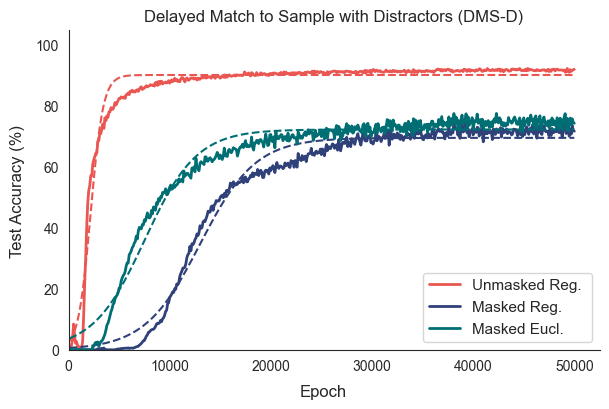

In [49]:
# ---- Mean accuracy curves + logistic fits (dashed), with fit R^2 ----
# Solid = mean test accuracy; dashed = logistic fit to that mean curve.
# No CI bands, no t_conv lines (cf. the convergence figure above).
if not check_only:

    def _r2(y, yhat):
        ss_res = np.sum((y - yhat) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    f_fit, _ = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                            squeeze=True, sharex=False, sharey=True)

    # solid mean curve + dashed logistic fit (fit to the mean curve = `popt` in mean_fit)
    print('Logistic fit R^2 (fit to the mean accuracy curve — the dashed lines):')
    for (ti, ki), (xv, ymean, ylo, yhi, popt) in sorted(mean_fit.items()):
        ax = f_fit.axes[ti]
        ax.plot(xv, ymean, color=color_palette[ki], lw=2, label=str(kernel_labels[ki]))
        if popt is not None:
            yhat = logistic(xv, *popt)
            ax.plot(xv, yhat, color=color_palette[ki], lw=1.5, ls='--')
            print(f'  task {ti} / {str(kernel_labels[ki]):16s}: R^2 = {_r2(ymean, yhat):.4f}')

    # per-run fit R^2 (quality of the fits that feed t_conv)
    r2_perrun = {ki: [] for ki in range(n_kernels)}
    for model_idx in range(n_models):
        this = model_params.iloc[model_idx]
        ta = loaded_accuracy[model_idx]
        test_accuracy = np.stack([ta[r][1:] * 100 for r in range(this.n_runs)])
        ep_log = epochs_per_log if epochs_per_log is not None else loaded_log_freq[model_idx]
        n_keep = test_accuracy.shape[1]
        if n_epochs_plot is not None:
            n_keep = min(n_keep, max(1, round(n_epochs_plot / ep_log)))
        test_accuracy = test_accuracy[:, :n_keep]
        x = np.arange(1, n_keep + 1) * ep_log
        for run in range(test_accuracy.shape[0]):
            try:
                r2_perrun[this.kernel_index].append(
                    _r2(test_accuracy[run], logistic(x, *fit_logistic(x, test_accuracy[run]))))
            except Exception:
                pass
    print('\nPer-run logistic fit R^2 (mean ± SD across runs):')
    for ki in range(n_kernels):
        r = np.asarray(r2_perrun[ki], float)
        if r.size:
            print(f'  {str(kernel_labels[ki]):16s} n={r.size:3d}  {r.mean():.4f} ± {r.std(ddof=1):.4f}')

    # polish (match the convergence figure)
    for ti in range(n_tasks):
        ax = f_fit.axes[ti]
        ax.set_ylim([0, 105]); ax.set_xlim(left=0)
        ax.set_title(utils.get_task_label(task_names[ti]), fontsize=font_size)
        if ti == 0:
            ax.legend(loc='lower right')
    f_fit.text(0.51, 0.0, 'Epoch', ha='center', va='center')
    f_fit.text(0.0, 0.5, 'Test Accuracy (%)', ha='center', va='center', rotation='vertical')
    sns.despine(fig=f_fit, right=True, top=True)
    f_fit.tight_layout(); plt.show()

    if save_figs:
        f_fit.savefig(os.path.join(outdir, 'performance_plots_with_fits.svg'),
                      dpi=300, bbox_inches='tight', pad_inches=0.01)

# Final-epoch performance spread (per-run)

Violins of converged test accuracy (last logged epoch) per model. Diagnostic for the euclidean-specific curriculum/seed sensitivity: is the **run-to-run spread** of converged performance larger for the Eucl. bioRNN than for Vanilla / Masked? The fair contrast is **Eucl vs Masked** (both mid-range, ~60%); Vanilla sits near ceiling where variance is compressed.

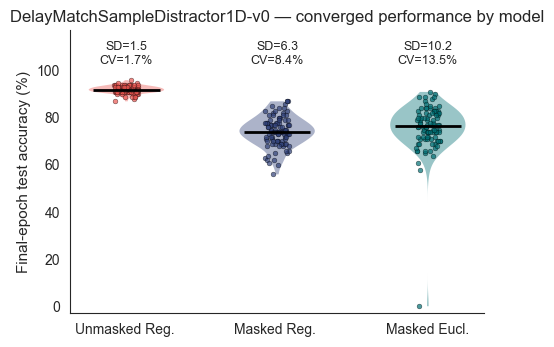

Per-run final accuracy (last logged epoch):
  Unmasked Reg.    n=100  mean= 92.0  median= 92.0  SD= 1.5  IQR= 2.0
  Masked Reg.      n=100  mean= 74.3  median= 74.0  SD= 6.3  IQR= 8.0
  Masked Eucl.     n=100  mean= 75.9  median= 76.5  SD=10.2  IQR=10.0

Brown-Forsythe equal-variance (all 3): W=25.49, p=6.07e-11
  Masked Eucl. vs Unmasked Reg.   : SD 10.2 vs 1.5  ->  W=39.50, p=2.05e-09
  Masked Eucl. vs Masked Reg.     : SD 10.2 vs 6.3  ->  W=2.56, p=1.11e-01   <- matched-regime contrast


In [50]:
# ---- Per-run final-epoch accuracy: distribution & variance by model ----
from scipy import stats as sstats
utils.set_font_size(11)

# last logged epoch of each run (full 60k horizon), as percent
final_acc = {}
for model_idx in range(n_models):
    k = model_params.kernel_label.iloc[model_idx]
    final_acc[k] = np.array([loaded_accuracy[model_idx][r][-1] * 100
                             for r in range(len(loaded_accuracy[model_idx]))])

order = [model_params.kernel_label.iloc[m] for m in range(n_models)]
colors = utils.get_my_colors(cat_trio=True, as_list=True)[:n_models]
data = [final_acc[k] for k in order]

fig, ax = plt.subplots(figsize=(5, 3.6))
parts = ax.violinplot(data, showextrema=False)
for pc, c in zip(parts['bodies'], colors):
    pc.set_facecolor(c); pc.set_alpha(0.4); pc.set_edgecolor('none')
rng = np.random.default_rng(0)
ymax = max(d.max() for d in data); ymin = min(d.min() for d in data)
for i, (k, c) in enumerate(zip(order, colors), start=1):
    y = final_acc[k]
    ax.scatter(i + rng.uniform(-0.08, 0.08, size=len(y)), y,
               s=12, color=c, edgecolor='k', linewidth=0.3, alpha=0.7, zorder=3)
    ax.hlines(np.median(y), i - 0.22, i + 0.22, color='k', lw=2, zorder=4)
    ax.text(i, ymax + (ymax - ymin) * 0.06,
            f'SD={y.std(ddof=1):.1f}\nCV={y.std(ddof=1) / y.mean() * 100:.1f}%',
            ha='center', va='bottom', fontsize=9)
ax.set_ylim(ymin - 3, ymax + (ymax - ymin) * 0.22)
ax.set_xticks(range(1, n_models + 1)); ax.set_xticklabels(order)
ax.set_ylabel('Final-epoch test accuracy (%)')
ax.set_title(f'{task_names[0]} — converged performance by model')
sns.despine(); fig.tight_layout()
if save_figs:
    fig.savefig(os.path.join(outdir, 'performance_final_accuracy_violins.svg'),
                dpi=300, bbox_inches='tight', pad_inches=0.01)
plt.show()

# ---- Is Eucl more variable? Brown-Forsythe (Levene, median-centered) ----
print('Per-run final accuracy (last logged epoch):')
for k in order:
    y = final_acc[k]
    print(f'  {k:16s} n={len(y):3d}  mean={y.mean():5.1f}  median={np.median(y):5.1f}  '
          f'SD={y.std(ddof=1):4.1f}  IQR={np.percentile(y, 75) - np.percentile(y, 25):4.1f}')

W, pval = sstats.levene(*data, center='median')
print(f'\nBrown-Forsythe equal-variance (all {n_models}): W={W:.2f}, p={pval:.2e}')
eucl_k = next((k for k in order if 'Eucl' in k), None)
if eucl_k:
    for k in order:
        if k == eucl_k:
            continue
        s, pp = sstats.levene(final_acc[eucl_k], final_acc[k], center='median')
        print(f'  {eucl_k} vs {k:16s}: SD {final_acc[eucl_k].std(ddof=1):.1f} vs '
              f'{final_acc[k].std(ddof=1):.1f}  ->  W={s:.2f}, p={pp:.2e}'
              + ('   <- matched-regime contrast' if 'Masked' in k and 'Eucl' not in k else ''))

# Training loss

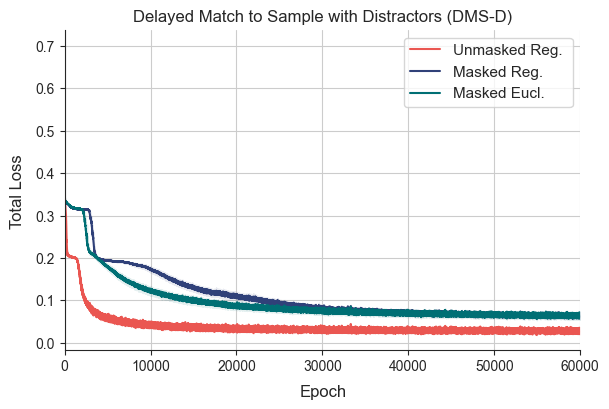

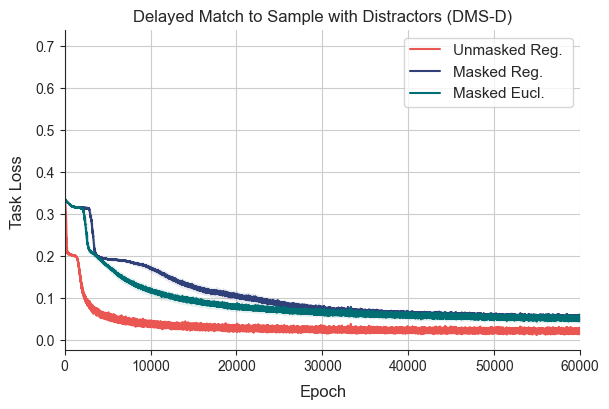

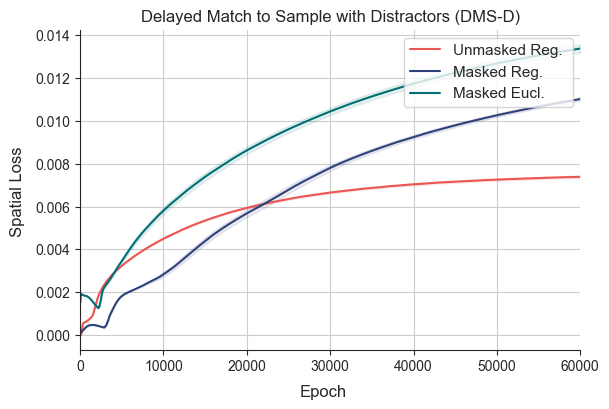

In [51]:
if not check_only:
    
    color_palette = utils.get_my_colors(cat_trio=False, as_list=True)
    loss_labels = ['Total Loss', 'Task Loss', 'Spatial Loss']
    loss_data_list = [loaded_loss, loaded_loss_task, loaded_loss_spatial]

    size_scale = 2.0
    font_size = int(6 * size_scale)
    plt.rcParams['font.size'] = font_size

    # create one figure per loss type
    for loss_type_idx, (loss_data, loss_label) in enumerate(zip(loss_data_list, loss_labels)):
        
        n_fig_columns = min((3, n_tasks))
        n_fig_rows = math.ceil(n_tasks / n_fig_columns)
        fig_size_w = 3 * n_fig_columns * size_scale
        fig_size_h = 2 * n_fig_rows * size_scale
        f_loss, ax_loss = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w, fig_size_h),
                                       squeeze=True, sharex=False, sharey=True)
        xlims = np.zeros(n_tasks)
        
        for model_idx in range(n_models):
            
            this = model_params.iloc[model_idx]
            
            if loss_data[model_idx] is None:
                print(f"No {loss_label.lower()} data for model {model_idx}")
                continue
            
            try:
                loss_all_runs = loss_data[model_idx]
                n_runs = min(this.n_runs, len(loss_all_runs))
                
                # shift initial delay?
                if 'spatial_only_epochs' in this.keys() and 1:
                    so_shift = this.spatial_only_epochs
                else:
                    so_shift = 0
                
                # extract loss from each run
                min_len = (min(len(loss_all_runs[r]) for r in range(n_runs))) - so_shift 
                # min_len = min((min_len,10000)) # <<<<<< choose number of epochs
                loss_array = np.zeros((n_runs, min_len))
                for run in range(n_runs):
                    loss_array[run, :] = loss_all_runs[run][so_shift:so_shift+min_len]
                if smooth_data > 0:
                    loss_array = uniform_filter1d(input=loss_array, size=smooth_data, axis=1)
                
                # create x axis (epochs)
                x = np.arange(1, min_len + 1)
                
                # compute mean and CI across runs
                loss_mean = loss_array.mean(axis=0)
                loss_std = loss_array.std(axis=0)
                ci = 1.96 * (loss_std / np.sqrt(n_runs))
                ci_lower = loss_mean - ci
                ci_upper = loss_mean + ci
                
                # plot
                ax = f_loss.axes[this.task_index] if hasattr(f_loss, 'axes') else f_loss
                ax.plot(x, loss_mean, color=color_palette[this.kernel_index],
                        label=str(this.kernel_label))
                ax.fill_between(x, ci_lower, ci_upper,
                               color=color_palette[this.kernel_index], alpha=0.1)
                xlims[this.task_index] = max(xlims[this.task_index], min_len)
                
            except Exception as e:
                print(f"Error plotting {loss_label} for model {model_idx}: {e}")
        
        # polish plots
        axes_list = f_loss.axes if hasattr(f_loss, 'axes') else [f_loss]
        for task_index in range(n_tasks):
            ax = axes_list[task_index]
            xmax = xlims[task_index]
            if xmax > 0:
                ax.set_xlim([0, xmax])
            ax.tick_params(bottom=True, left=True)
            if task_index == 0:
                ax.legend(loc='upper right')
            ax.set_title(utils.get_task_label(task_names[task_index]), fontsize=font_size)
            ax.grid()
        f_loss.text(0.51, 0.0, 'Epoch', ha='center', va='center')
        f_loss.text(0.0, 0.5, loss_label, ha='center', va='center', rotation='vertical')
        
        sns.despine(fig=f_loss, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
        f_loss.tight_layout()
        plt.show()
        
        # save svg
        if save_figs:
            models_file = os.path.splitext(os.path.basename(model_params_file))[0]
            loss_suffix = loss_label.lower().replace(' ', '_')
            f_loss.savefig(os.path.join(outdir, '{:}_{:}.svg'.format(loss_suffix, models_file)),
                           dpi=300, bbox_inches='tight', pad_inches=0.01)